In [1]:
from hnn_core.optimization import Optimizer, add_opt_drives, set_params_opt_drives
from hnn_core.optimization.objective_functions import _check_is_batch
from hnn_core.batch_simulate import BatchSimulate
from hnn_core import jones_2009_model, simulate_dipole
from hnn_core.network_models import add_erp_drives_to_jones_model
from hnn_core.extracellular import calculate_csd2d, _get_laminar_z_coords
from hnn_core.dipole import _corr

import pickle
from hnn_core import JoblibBackend

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.interpolate import CubicSpline

--No graphics will be displayed.


In [2]:
df_csd1 = pd.read_csv('../data/2-pb3738017_trace8_with_time.txt', delimiter=' ')
cs_csd1 = CubicSpline(df_csd1['time_ms'], df_csd1['csd_trace8'])

df_csd2 = pd.read_csv('../data/2-pb3738017_trace16_with_time.txt', delimiter=' ')
cs_csd2 = CubicSpline(df_csd2['time_ms'], df_csd2['csd_trace16'])

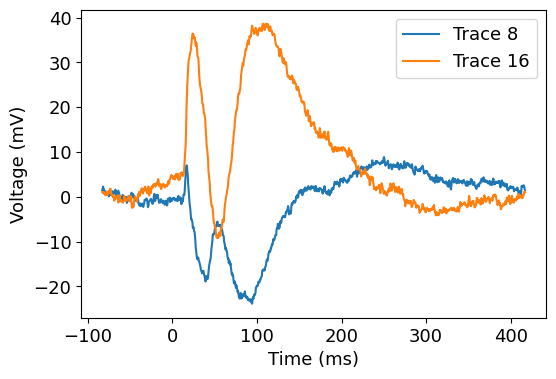

In [3]:
labelsize = 13
ticksize = 13
legendsize = 13

plt.figure(figsize=(6,4))
plt.plot(df_csd1['time_ms'], df_csd1['csd_trace8'], label='Trace 8')
plt.plot(df_csd2['time_ms'], df_csd2['csd_trace16'], label='Trace 16')
plt.xlabel('Time (ms)', fontsize=labelsize)
plt.ylabel('Voltage (mV)', fontsize=labelsize)
plt.xticks(fontsize=ticksize)
plt.yticks(fontsize=ticksize)
plt.legend(fontsize=legendsize)

In [4]:
n_trials = 1
scaling_factor = 1000
window_length = 40
tstop = 400
# dt = 0.025
dt = 0.5

max_iter = 100
popsize = 100

net = jones_2009_model()
add_erp_drives_to_jones_model(net)

depths = np.arange(-325, 2150, 100)
electrode_pos = [(135, 135, dep) for dep in depths]
net.add_electrode_array('shank1', electrode_pos)

dpl = simulate_dipole(net, tstop=tstop, dt=dt, verbose=False)

In [5]:
times = dpl[0].times

contact_labels, delta = _get_laminar_z_coords(net.rec_arrays['shank1'].positions)
hnn_csd_data = calculate_csd2d(lfp_data=net.rec_arrays['shank1'].voltages[0], delta=delta)

exp_csd1 = cs_csd1(times)
exp_csd2 = cs_csd2(times)

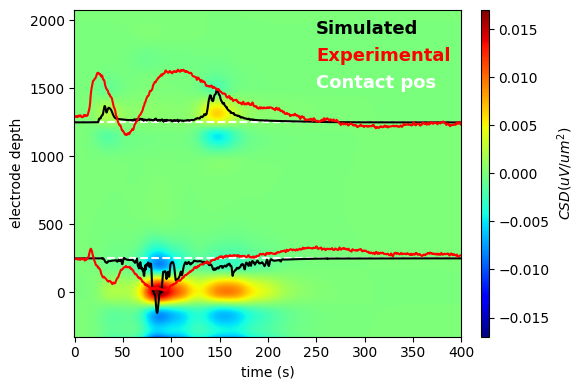

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(6,4),)

pos1, pos2 = 250, 1250
ax.axhline(pos1, color='white', linestyle='--')
ax.axhline(pos2, color='white', linestyle='--')

pos1_idx = np.argmin(np.abs(depths - pos1))
pos2_idx = np.argmin(np.abs(depths - pos2))

hnn_csd_scale = 3e4
plt.plot(times, hnn_csd_data[pos1_idx, :] * hnn_csd_scale + pos1, color='k')
plt.plot(times, hnn_csd_data[pos2_idx, :] * hnn_csd_scale + pos2, color='k')

exp_csd_scale = 10
plt.plot(times, exp_csd1 * exp_csd_scale + pos1, color='r')
plt.plot(times, exp_csd2 * exp_csd_scale + pos2, color='r')

ax.text(250, 1900, 'Simulated', color='k', weight='bold', fontsize=legendsize)
ax.text(250, 1700, 'Experimental', color='r', weight='bold', fontsize=legendsize)
ax.text(250, 1500, 'Contact pos', color='white', weight='bold', fontsize=legendsize)


_ = net.rec_arrays['shank1'][0].smooth(window_len=window_length).plot_csd(ax=ax)


In [7]:
def _process_csd(net):
    contact_labels, delta = _get_laminar_z_coords(net.rec_arrays['shank1'].positions)
    hnn_csd_data = calculate_csd2d(lfp_data=net.rec_arrays['shank1'].voltages[0], delta=delta)

    depths = np.array(net.rec_arrays['shank1'].positions)[:, 2]
    pos1, pos2 = 250, 1250
    pos1_idx = np.argmin(np.abs(depths - pos1))
    pos2_idx = np.argmin(np.abs(depths - pos2))

    csd1 = hnn_csd_data[pos1_idx, :]
    csd2 = hnn_csd_data[pos2_idx, :]
    return csd1, csd2



def _corr_csd(
    initial_net,
    initial_params,
    set_params,
    predicted_params,
    update_params,
    obj_values,
    tstop,
    obj_fun_kwargs,
):
    """The objective function for evoked responses.

    Parameters
    ----------
    initial_net : instance of Network
        The network object.
    initial_params : dict
        Keys are parameter names, values are initial parameters.
    set_params : func
        User-defined function that sets network drives and parameters.
    predicted_params : list
        Parameters selected by the optimizer.
    update_params : func
        Function to update params.
    tstop : float
        The simulated dipole's duration.
    target : instance of Dipole
        A dipole object with experimental data.
    n_trials : int
        Number of trials to simulate and average.
    verbose : bool
        If True, print build steps and simulation progress to console. Default: True.

    Returns
    -------
    obj : float
        Normalized RMSE between recorded and simulated dipole.
    """
    is_batch = _check_is_batch(predicted_params)

    if is_batch:
        # params = update_params(initial_params, predicted_params)
        predicted_params = np.array(predicted_params).reshape(-1, len(initial_params))
        params_batch = {
            name: predicted_params[:, idx]
            for idx, name in enumerate(initial_params.keys())
        }

        # simulate dpl with predicted params
        new_net = initial_net.copy()

        def set_params_batch(a, b):
            set_params(b, a)  # need to fix this

        batch_simulation = BatchSimulate(
            net=new_net,
            set_params=set_params_batch,
            save_outputs=False,
            save_dpl=True,
            dt=obj_fun_kwargs.get("dt", 0.025),
            n_trials=obj_fun_kwargs.get("n_trials", 1),
            tstop=tstop,
            overwrite=False,
            clear_cache=False,
        )

        res = batch_simulation.run(
            params_batch,
            n_jobs=obj_fun_kwargs.get("n_jobs", 1),
            combinations=False,
            backend="loky",
            verbose=obj_fun_kwargs.get("verbose", True),
        )

        csd1_list, csd2_list = list(), list()
        for batch_res in res["simulated_data"]:
            for data in batch_res:
                # smooth & scale all dipoles
                csd1, csd2 = _process_csd(data["net"])
                csd1_list.append(csd1)
                csd2_list.append(csd2)

        obj1 = [np.corrcoef(csd_res, obj_fun_kwargs["target"][0])[0,1] for csd_res in csd1_list]
        obj2 = [np.corrcoef(csd_res, obj_fun_kwargs["target"][1])[0,1] for csd_res in csd2_list]

        obj1 = 1 - np.array(obj1)
        obj2 = 1 - np.array(obj2)

        obj =  (obj1 + obj2) / 2
        obj_values.append(obj.tolist())

        print(f"Mean Loss: {np.mean(obj1):.2f}/{np.mean(obj2):.2f} ; Min Loss: {np.min(obj1):.2f}/{np.min(obj2):.2f}")
        return obj

    else:
        params = update_params(initial_params, predicted_params)

        # simulate dpl with predicted params
        new_net = initial_net.copy()
        set_params(new_net, params)

        dpls = simulate_dipole(
            new_net, tstop=tstop, n_trials=obj_fun_kwargs["n_trials"]
        )

        # smooth & scale all dipoles
        _preprocess_dipole(dpls, obj_fun_kwargs)
        dpl = average_dipoles(dpls)
        obj = _corr(dpl, obj_fun_kwargs["target"], tstop=tstop)

    print(f"Mean Loss: {np.mean(obj):.2f}; Min Loss: {np.min(obj):.2f}")
    obj_values.append(obj)

    return obj

In [8]:
net_base = jones_2009_model()
net_base.add_electrode_array('shank1', electrode_pos)

constraints, initial_params = add_opt_drives(net_base, n_prox=3, n_dist=3)

optim = Optimizer(net_base, tstop=tstop, constraints=constraints, solver='cma',
                set_params=set_params_opt_drives, initial_params=initial_params, max_iter=max_iter, obj_fun=_corr_csd)
                

target = [exp_csd1, exp_csd2]
optim.fit(target=target, n_trials=n_trials, scale_factor=scaling_factor,
          smooth_window_len=window_length, dt=dt, popsize=popsize, n_jobs=50, verbose=False)

(50_w,100)-aCMA-ES (mu_w=27.0,w_1=8%) in dimension 66 (seed=992200, Mon Mar 30 14:10:25 2026)


/oscar/home/ntolley/Jones_Lab/lcsd_opt/.pixi/envs/default/lib/python3.12/site-packages/hnn_core/optimization/general_optimization.py:101: UserWarning: The cma solver does not use initial_params.Values passed will not be used
  warn(


--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graph

Mean Loss: 0.49/0.50 ; Min Loss: 0.14/0.14
Mean Loss: 0.43/0.43 ; Min Loss: 0.12/0.17
Mean Loss: 0.38/0.37 ; Min Loss: 0.13/0.08
Mean Loss: 0.38/0.42 ; Min Loss: 0.13/0.08
Mean Loss: 0.31/0.38 ; Min Loss: 0.12/0.13
Mean Loss: 0.34/0.39 ; Min Loss: 0.10/0.09
Mean Loss: 0.34/0.40 ; Min Loss: 0.13/0.09
Mean Loss: 0.33/0.43 ; Min Loss: 0.11/0.13
Mean Loss: 0.32/0.45 ; Min Loss: 0.12/0.16
Mean Loss: 0.31/0.42 ; Min Loss: 0.13/0.10
Mean Loss: 0.30/0.40 ; Min Loss: 0.13/0.08
Mean Loss: 0.32/0.41 ; Min Loss: 0.11/0.10
Mean Loss: 0.31/0.40 ; Min Loss: 0.12/0.12
Mean Loss: 0.33/0.40 ; Min Loss: 0.13/0.11
Mean Loss: 0.30/0.41 ; Min Loss: 0.12/0.11
Mean Loss: 0.33/0.39 ; Min Loss: 0.11/0.08
Mean Loss: 0.29/0.41 ; Min Loss: 0.11/0.14
Mean Loss: 0.29/0.38 ; Min Loss: 0.09/0.09
Mean Loss: 0.28/0.41 ; Min Loss: 0.09/0.12
Mean Loss: 0.31/0.37 ; Min Loss: 0.10/0.11
Mean Loss: 0.28/0.36 ; Min Loss: 0.09/0.09
Mean Loss: 0.27/0.37 ; Min Loss: 0.10/0.10
Mean Loss: 0.27/0.40 ; Min Loss: 0.12/0.13
Mean Loss: 

In [26]:
# # Save parameters of best fit network
# optim.net_.write_configuration(f'../data/opt_csd_config.json')

# Save optimizer class
# with open(f'../data/opt_csd_results.pkl', 'wb') as file:
#     pickle.dump(optim, file)



In [16]:
# Run best fit dipole:
with JoblibBackend(n_jobs=10):
    dipoles_optimized = simulate_dipole(
            optim.net_, tstop=tstop, n_trials=10, dt=dt, verbose=False)

--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.
--No graphics will be displayed.


In [19]:
times = dpl[0].times

contact_labels, delta = _get_laminar_z_coords(optim.net_.rec_arrays['shank1'].positions)
opt_csd_data = calculate_csd2d(lfp_data=optim.net_.rec_arrays['shank1'].voltages[0], delta=delta)

exp_csd1 = cs_csd1(times)
exp_csd2 = cs_csd2(times)

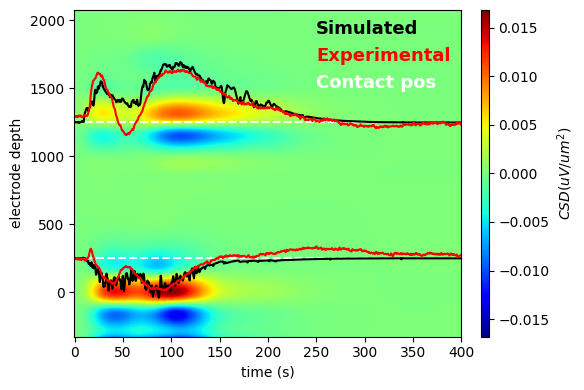

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(6,4),)

pos1, pos2 = 250, 1250
ax.axhline(pos1, color='white', linestyle='--')
ax.axhline(pos2, color='white', linestyle='--')

pos1_idx = np.argmin(np.abs(depths - pos1))
pos2_idx = np.argmin(np.abs(depths - pos2))

opt_csd_scale = 5e4
plt.plot(times, opt_csd_data[pos1_idx, :] * opt_csd_scale + pos1, color='k')
plt.plot(times, opt_csd_data[pos2_idx, :] * opt_csd_scale + pos2, color='k')

exp_csd_scale = 10
plt.plot(times, exp_csd1 * exp_csd_scale + pos1, color='r')
plt.plot(times, exp_csd2 * exp_csd_scale + pos2, color='r')

ax.text(250, 1900, 'Simulated', color='k', weight='bold', fontsize=legendsize)
ax.text(250, 1700, 'Experimental', color='r', weight='bold', fontsize=legendsize)
ax.text(250, 1500, 'Contact pos', color='white', weight='bold', fontsize=legendsize)


_ = optim.net_.rec_arrays['shank1'][0].copy().smooth(window_len=window_length).plot_csd(ax=ax)
